# Capítulo 3: Análise Exploratória de Dados
Este notebook replica as principais implementações práticas de tabelas e gráficos discutidos no Capítulo 3 do livro *Estatística para Cursos de Engenharia, Computação e Ciência de Dados*.

## 1. Importando Bibliotecas e Criando Dados de Exemplo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

# Gerando dados sintéticos (ex: tempo de processamento de um script em segundos)
np.random.seed(42)
dados_quantitativos = np.random.normal(loc=50, scale=10, size=100)

# Adicionando alguns outliers intencionalmente para enriquecer o Boxplot
dados_quantitativos = np.append(dados_quantitativos, [85, 92, 12])

# Dados qualitativos (categorias de falhas de hardware/software)
categorias = ['Falha de Rede', 'Erro de Software', 'Timeout', 'Bug de Interface']
dados_qualitativos = np.random.choice(categorias, size=150, p=[0.4, 0.3, 0.2, 0.1])

df_qualitativo = pd.DataFrame({'Categoria': dados_qualitativos})
print("Dados inicializados com sucesso!")

Dados inicializados com sucesso!


## 2. Organização de Dados e Tabelas de Frequência

In [2]:
# Tabela de frequências para Variável Qualitativa
f_absoluta = df_qualitativo['Categoria'].value_counts()
f_relativa = df_qualitativo['Categoria'].value_counts(normalize=True) * 100

tab_qualitativa = pd.DataFrame({
    'Frequência Absoluta (fi)': f_absoluta,
    'Frequência Relativa (%)': f_relativa
})
print("--- Tabela de Frequência (Variável Qualitativa) ---")
display(tab_qualitativa)

--- Tabela de Frequência (Variável Qualitativa) ---


,Frequência Absoluta (fi),Frequência Relativa (%)
Categoria,,
Falha de Rede,60,40.000000
Erro de Software,43,28.666667
Timeout,29,19.333333
Bug de Interface,18,12.000000


In [6]:
# Tabela de frequências em classes para Variável Quantitativa Contínua
classes = pd.cut(dados_quantitativos, bins=7)
f_abs_quant = pd.Series(classes).value_counts().sort_index()
f_rel_quant = (f_abs_quant / f_abs_quant.sum()) * 100
f_acum_quant = f_rel_quant.cumsum()

tab_quantitativa = pd.DataFrame({
    'Frequência Absoluta (fi)': f_abs_quant,
    'Frequência Relativa (%)': f_rel_quant,
    'Frequência Acumulada (%)': f_acum_quant
})
print("\n--- Tabela de Frequência em Classes (Variável Quantitativa) ---")
display(tab_quantitativa.style.format({
    'Frequência Relativa (%)': '{:.2f}',
    'Frequência Acumulada (%)': '{:.2f}'
}))


--- Tabela de Frequência em Classes (Variável Quantitativa) ---


,Frequência Absoluta (fi),Frequência Relativa (%),Frequência Acumulada (%)
"(11.92, 23.429]",1,0.97,0.97
"(23.429, 34.857]",6,5.83,6.80
"(34.857, 46.286]",32,31.07,37.86
"(46.286, 57.714]",44,42.72,80.58
"(57.714, 69.143]",18,17.48,98.06
"(69.143, 80.571]",0,0.00,98.06
"(80.571, 92.0]",2,1.94,100.00


## 3. Representação Gráfica dos Dados

C:\Users\Cleuler\AppData\Local\Temp\ipykernel_5268\2319747642.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tab_qualitativa.index, y='Frequência Absoluta (fi)', data=tab_qualitativa, palette='viridis')


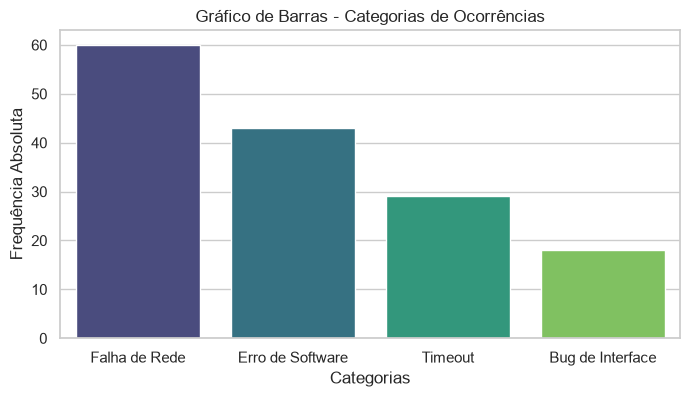

In [7]:
# Gráfico de Barras para Variáveis Qualitativas
plt.figure(figsize=(8, 4))
sns.barplot(x=tab_qualitativa.index, y='Frequência Absoluta (fi)', data=tab_qualitativa, palette='viridis')
plt.title('Gráfico de Barras - Categorias de Ocorrências')
plt.xlabel('Categorias')
plt.ylabel('Frequência Absoluta')
plt.show()

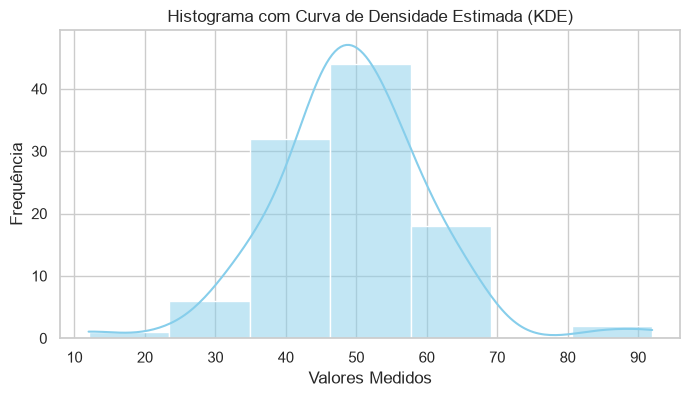

In [8]:
# Histograma para Variável Quantitativa Contínua
plt.figure(figsize=(8, 4))
sns.histplot(dados_quantitativos, bins=7, kde=True, color='skyblue')
plt.title('Histograma com Curva de Densidade Estimada (KDE)')
plt.xlabel('Valores Medidos')
plt.ylabel('Frequência')
plt.show()

## 4. Medidas de Posição Central e Dispersão

In [ ]:
# Cálculo das Estatísticas Descritivas Principais
media = np.mean(dados_quantitativos)
mediana = np.median(dados_quantitativos)
variancia = np.var(dados_quantitativos, ddof=1) # ddof=1 para variância amostral
desvio_padrao = np.std(dados_quantitativos, ddof=1)
coef_variacao = (desvio_padrao / media) * 100
amplitude = np.max(dados_quantitativos) - np.min(dados_quantitativos)

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Amplitude Total: {amplitude:.2f}")
print(f"Variância Amostral: {variancia:.2f}")
print(f"Desvio Padrão Amostral: {desvio_padrao:.2f}")
print(f"Coeficiente de Variação: {coef_variacao:.2f}%")

## 5. Diagrama de Caixa (Boxplot) e Identificação de Outliers

In [ ]:
# Visualização e cálculo dos Quartis
q1 = np.percentile(dados_quantitativos, 25)
q3 = np.percentile(dados_quantitativos, 75)
iqr = q3 - q1

print(f"Primeiro Quartil (Q1): {q1:.2f}")
print(f"Terceiro Quartil (Q3): {q3:.2f}")
print(f"Amplitude Interquartílica (IQR): {iqr:.2f}")

# Gerando o Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(y=dados_quantitativos, color='lightgreen', width=0.4)
plt.title('Diagrama de Caixa (Boxplot)')
plt.ylabel('Valores Medidos')
plt.show()